In [9]:
import itertools

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# Simulated Time Series Data
np.random.seed(42)
data = pd.Series(np.cumsum(np.random.randn(200)))  # Random walk time series

# Create Features: Lagged Values and Rate of Change
df = pd.DataFrame(
    {
        "value": data,
        "lag_1": data.shift(1),
        "lag_2": data.shift(2),
        "rate_of_change": data.diff(),
    }
).dropna()

# Target for Classification: 1 if increase, 0 if decrease
df["direction"] = (df["value"].shift(-1) > df["value"]).astype(int)

# Target for Regression: Next Value
df["next_value"] = df["value"].shift(-1)

# Drop NaN Rows
df = df.dropna()

# Train-Test Split
X = df[["value", "lag_1", "lag_2", "rate_of_change"]]
y_class = df["direction"]
y_reg = df["next_value"]
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = (
    train_test_split(X, y_class, y_reg, test_size=0.2, random_state=42)
)


# Classification Model: Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_class_train)

# Add Classification Predictions as a Feature for Regression
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()
X_train_reg["direction_pred"] = clf.predict(X_train)
X_test_reg["direction_pred"] = clf.predict(X_test)

# Regression Model: Random Forest Regressor
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_reg_train)

# Predict Values
y_class_pred = clf.predict(X_test)
y_reg_pred = reg.predict(X_test_reg)

# Evaluate Performance
accuracy = accuracy_score(y_class_test, y_class_pred)
mae = mean_absolute_error(y_reg_test, y_reg_pred)

print(f"Classification Accuracy: {accuracy:.2f}")
print(f"Regression Mean Absolute Error: {mae:.2f}")

# ARIMA
# Create a time index for the training data
train_index = pd.date_range(start="2000-01-01", periods=len(y_reg_train), freq="D")
y_reg_train_series = pd.Series(y_reg_train.values, index=train_index)

# Define the p, d and q parameters to take any value between 0 and 2
p = d = q = range(0, 3)

# Generate all different combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))

# Ensure Data Stationarity (optional: use differencing if necessary)
y_reg_train_series = y_reg_train_series.diff().dropna()

# Grid Search for ARIMA Parameters
best_aic = np.inf
best_pdq = None
best_model = None

for param in pdq:
    try:
        model_arima = ARIMA(y_reg_train_series, order=param)
        results_arima = model_arima.fit()
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_pdq = param
            best_model = results_arima
    except Exception as e:
        print(f"ARIMA{param} failed: {e}")
        continue

if best_model is not None:
    print(f"Best ARIMA model: ARIMA{best_pdq}")

    # Forecast
    forecast = best_model.get_forecast(steps=len(y_reg_test))
    y_reg_pred_arima = forecast.predicted_mean

    # Evaluate Performance
    mae_arima = mean_absolute_error(y_reg_test, y_reg_pred_arima)
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")
else:
    print("No valid ARIMA model found.")

print(f"Best ARIMA model: ARIMA{best_pdq}")
# Forecast
forecast_index = pd.date_range(
    start=train_index[-1] + pd.Timedelta(days=1), periods=len(y_reg_test), freq="D"
)
forecast = best_model.forecast(steps=len(y_reg_test))
y_reg_pred_arima = forecast

# Evaluate Performance
accuracy_rf = accuracy_score(y_class_test, clf.predict(X_test))
mae_rf = mean_absolute_error(y_reg_test, y_reg_pred_rf)
mae_arima = mean_absolute_error(y_reg_test, y_reg_pred_arima)

print(f"Classification Accuracy (Random Forest): {accuracy_rf:.2f}")
print(f"Regression Mean Absolute Error (Random Forest): {mae_rf:.2f}")
print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")

Classification Accuracy: 0.65
Regression Mean Absolute Error: 0.87


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/

Best ARIMA model: ARIMA(0, 0, 1)
Regression Mean Absolute Error (ARIMA): 8.37
Best ARIMA model: ARIMA(0, 0, 1)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


NameError: name 'y_reg_pred_rf' is not defined

In [3]:
!pip install itertools

ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools


In [7]:
from statsmodels.tsa.arima.model import ARIMA  # Updated import

# Ensure Data Stationarity (optional: use differencing if necessary)
y_reg_train_series = y_reg_train_series.diff().dropna()

# Grid Search for ARIMA Parameters
best_aic = np.inf
best_pdq = None
best_model = None

for param in pdq:
    try:
        model_arima = ARIMA(y_reg_train_series, order=param)
        results_arima = model_arima.fit()
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_pdq = param
            best_model = results_arima
    except Exception as e:
        print(f"ARIMA{param} failed: {e}")
        continue

if best_model is not None:
    print(f"Best ARIMA model: ARIMA{best_pdq}")

    # Forecast
    forecast = best_model.get_forecast(steps=len(y_reg_test))
    y_reg_pred_arima = forecast.predicted_mean

    # Evaluate Performance
    mae_arima = mean_absolute_error(y_reg_test, y_reg_pred_arima)
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")
else:
    print("No valid ARIMA model found.")

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/

Best ARIMA model: ARIMA(0, 0, 1)
Regression Mean Absolute Error (ARIMA): 8.37


In [11]:
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Suppress ARIMA warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
warnings.filterwarnings("ignore", category=UserWarning)

# Ensure Data Stationarity (Differencing)
y_reg_train_series = y_reg_train_series.diff().dropna()

# Check Stationarity (Optional)
adf_test = adfuller(y_reg_train_series)
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
if adf_test[1] > 0.05:
    print("Warning: Time series is not stationary!")

# Grid Search for ARIMA Parameters
best_aic = np.inf
best_pdq = None
best_model = None

for param in pdq:
    try:
        model_arima = ARIMA(y_reg_train_series, order=param)
        results_arima = model_arima.fit()
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_pdq = param
            best_model = results_arima
    except Exception as e:
        print(f"ARIMA{param} failed: {e}")
        continue

if best_model is not None:
    print(f"Best ARIMA model: ARIMA{best_pdq}")

    # Forecast
    forecast = best_model.get_forecast(steps=len(y_reg_test))
    y_reg_pred_arima = forecast.predicted_mean

    # Evaluate Performance
    mae_arima = mean_absolute_error(y_reg_test, y_reg_pred_arima)
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")
else:
    print("No valid ARIMA model found.")

# Evaluate Random Forest Performance
accuracy_rf = accuracy_score(y_class_test, clf.predict(X_test))
mae_rf = mean_absolute_error(y_reg_test, y_reg_pred)  # Corrected variable

print(f"Classification Accuracy (Random Forest): {accuracy_rf:.2f}")
print(f"Regression Mean Absolute Error (Random Forest): {mae_rf:.2f}")

ADF Statistic: -8.075795492281689
p-value: 1.5067755722918111e-12
Best ARIMA model: ARIMA(1, 0, 2)
Regression Mean Absolute Error (ARIMA): 8.45
Classification Accuracy (Random Forest): 0.65
Regression Mean Absolute Error (Random Forest): 0.87


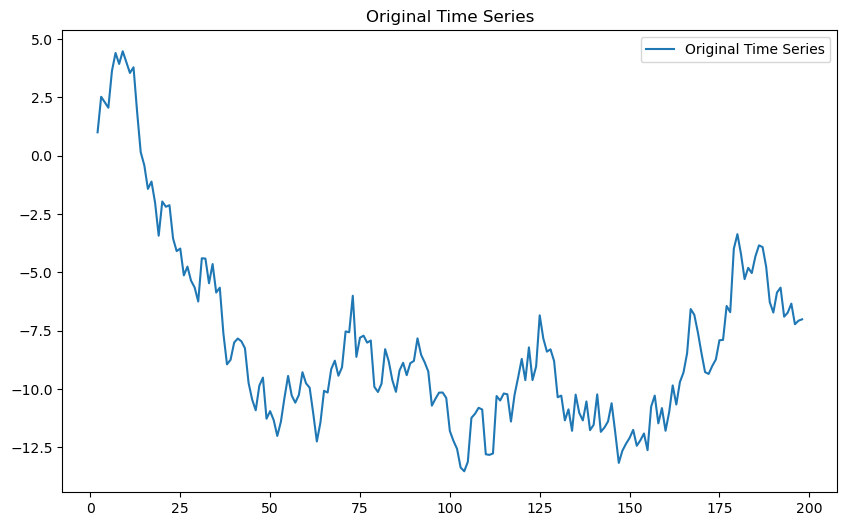

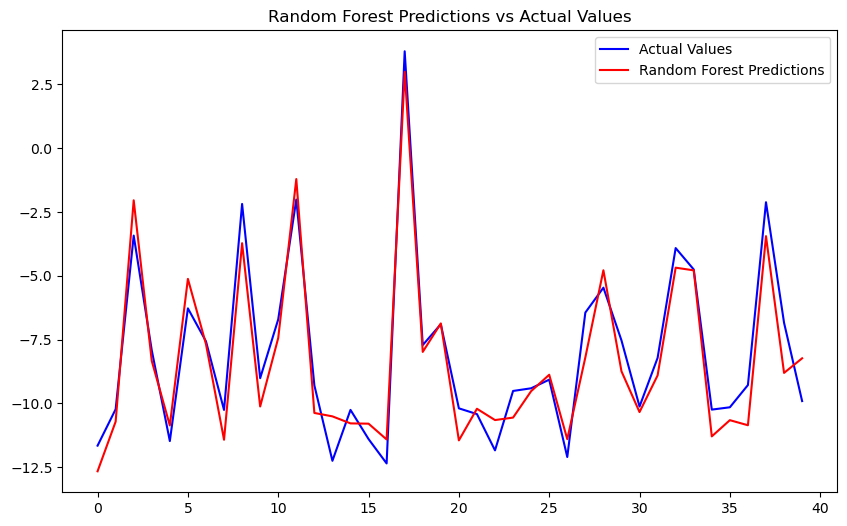

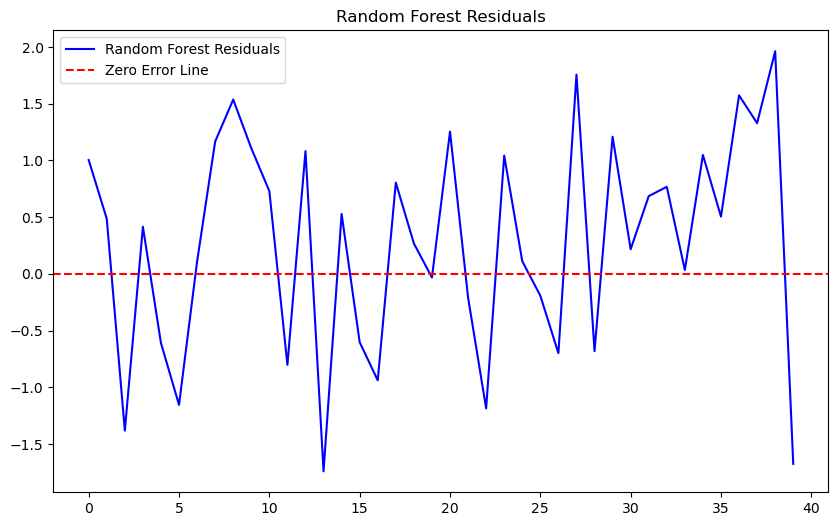

ADF Statistic: -7.403501701868878
p-value: 7.448203340014005e-11
Best ARIMA model: ARIMA(0, 0, 1)
Regression Mean Absolute Error (ARIMA): 2.62


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


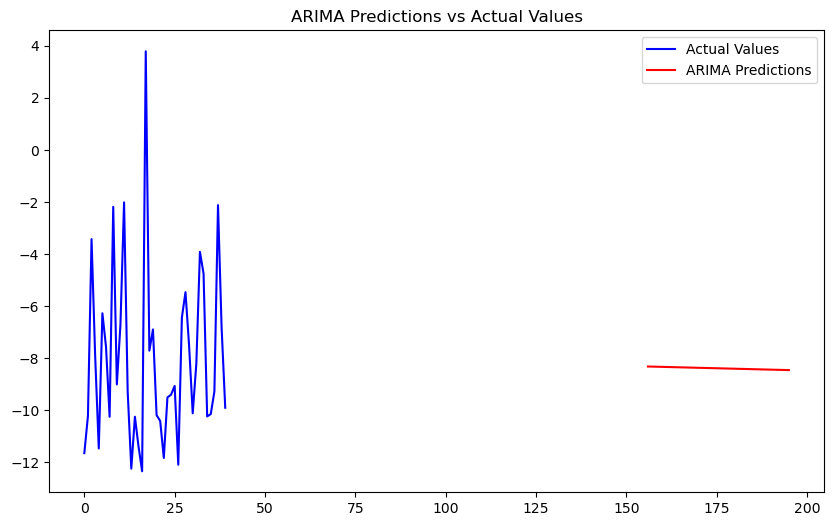

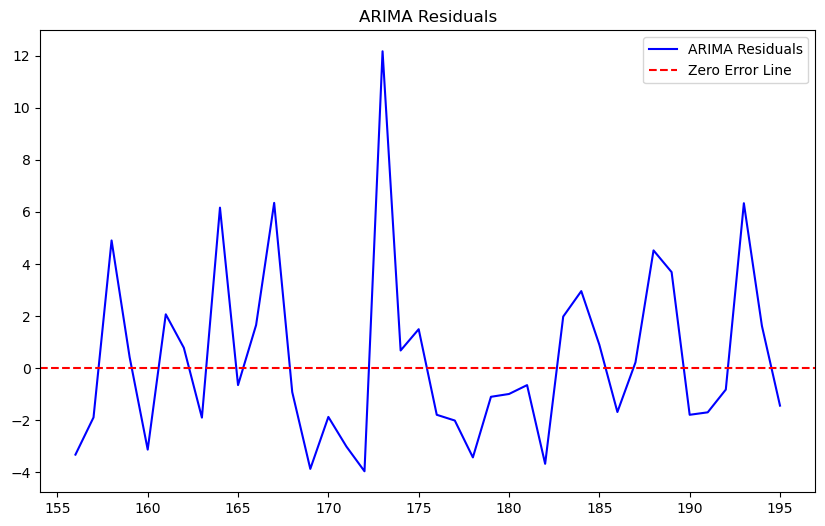

Classification Accuracy (Random Forest): 0.65
Regression Mean Absolute Error (Random Forest): 0.87
Regression Mean Absolute Error (ARIMA): 2.62


In [19]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Suppress ARIMA warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
warnings.filterwarnings("ignore", category=UserWarning)

# Simulated Time Series Data
np.random.seed(42)
data = pd.Series(np.cumsum(np.random.randn(200)))  # Random walk time series

# Create Features: Lagged Values and Rate of Change
df = pd.DataFrame(
    {
        "value": data,
        "lag_1": data.shift(1),
        "lag_2": data.shift(2),
        "rate_of_change": data.diff(),
    }
).dropna()

# Target for Classification: 1 if increase, 0 if decrease
df["direction"] = (df["value"].shift(-1) > df["value"]).astype(int)

# Target for Regression: Next Value
df["next_value"] = df["value"].shift(-1)

# Drop NaN Rows
df = df.dropna()

# Train-Test Split
X = df[["value", "lag_1", "lag_2", "rate_of_change"]]
y_class = df["direction"]
y_reg = df["next_value"]
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = (
    train_test_split(X, y_class, y_reg, test_size=0.2, random_state=42)
)

# Classification Model: Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_class_train)

# Add Classification Predictions as a Feature for Regression
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()
X_train_reg["direction_pred"] = clf.predict(X_train)
X_test_reg["direction_pred"] = clf.predict(X_test)

# Regression Model: Random Forest Regressor
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_reg_train)

# Predict Values
y_class_pred = clf.predict(X_test)
y_reg_pred = reg.predict(X_test_reg)

# Evaluate Performance
accuracy = accuracy_score(y_class_test, y_class_pred)
mae_rf = mean_absolute_error(y_reg_test, y_reg_pred)

# Plot Original Time Series
plt.figure(figsize=(10, 6))
plt.plot(df["value"], label="Original Time Series")
plt.title("Original Time Series")
plt.legend()
plt.savefig("original_time_series.png")
plt.show()

# Plot Predictions vs Actual (Random Forest)
plt.figure(figsize=(10, 6))
plt.plot(y_reg_test.values, label="Actual Values", color="Blue")
plt.plot(y_reg_pred, label="Random Forest Predictions", color="Red")
plt.title("Random Forest Predictions vs Actual Values")
plt.legend()
plt.savefig("random_forest_predictions.png")
plt.show()

# Plot Residuals (Random Forest)
residuals_rf = y_reg_test.values - y_reg_pred
plt.figure(figsize=(10, 6))
plt.plot(residuals_rf, label="Random Forest Residuals", color="Blue")
plt.axhline(0, color="red", linestyle="--", label="Zero Error Line")
plt.title("Random Forest Residuals")
plt.legend()
plt.savefig("random_forest_residuals.png")
plt.show()

# ARIMA Model
y_reg_train_series = y_reg_train.diff().dropna()

# Check Stationarity (Optional)
adf_test = adfuller(y_reg_train_series)
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
if adf_test[1] > 0.05:
    print("Warning: Time series is not stationary!")

# Grid Search for ARIMA Parameters
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
best_aic = np.inf
best_pdq = None
best_model = None

for param in pdq:
    try:
        model_arima = ARIMA(y_reg_train_series, order=param)
        results_arima = model_arima.fit()
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_pdq = param
            best_model = results_arima
    except:
        continue

if best_model is not None:
    print(f"Best ARIMA model: ARIMA{best_pdq}")
    forecast = best_model.get_forecast(steps=len(y_reg_test))
    y_reg_pred_arima_diff = forecast.predicted_mean  # Predicted differenced values

    # Reverse differencing to match the original scale
    last_value = y_reg_train.iloc[-1]  # Last value from the training data
    y_reg_pred_arima = np.cumsum(y_reg_pred_arima_diff) + last_value

    # Evaluate ARIMA Performance
    mae_arima = mean_absolute_error(y_reg_test, y_reg_pred_arima)
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")

    # Plot Residuals (ARIMA)
    residuals_arima = y_reg_test.values - y_reg_pred_arima
    plt.figure(figsize=(10, 6))
    plt.plot(residuals_arima, label="ARIMA Residuals", color="Blue")
    plt.axhline(0, color="red", linestyle="--", label="Zero Error Line")
    plt.title("ARIMA Residuals")
    plt.legend()
    plt.savefig("arima_residuals.png")
    plt.show()
else:
    print("No valid ARIMA model found.")


# Final Performance Comparison
print(f"Classification Accuracy (Random Forest): {accuracy:.2f}")
print(f"Regression Mean Absolute Error (Random Forest): {mae_rf:.2f}")
if best_model is not None:
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")

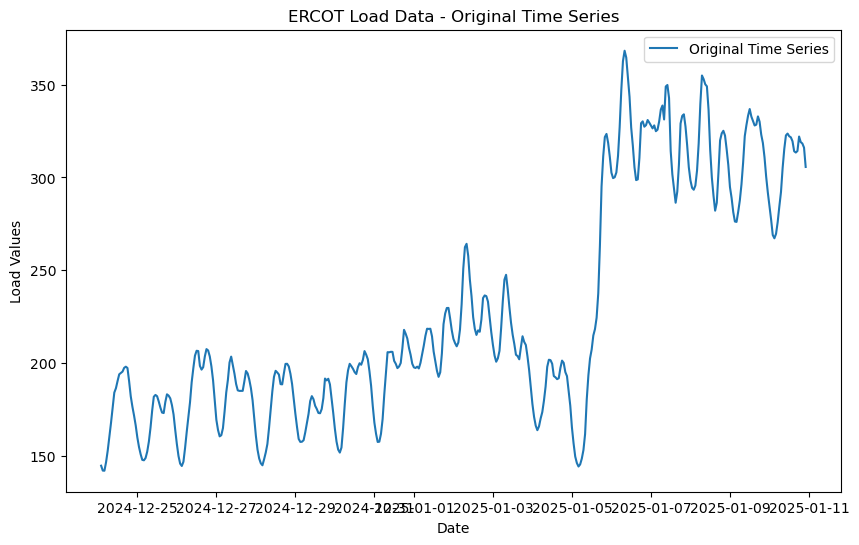

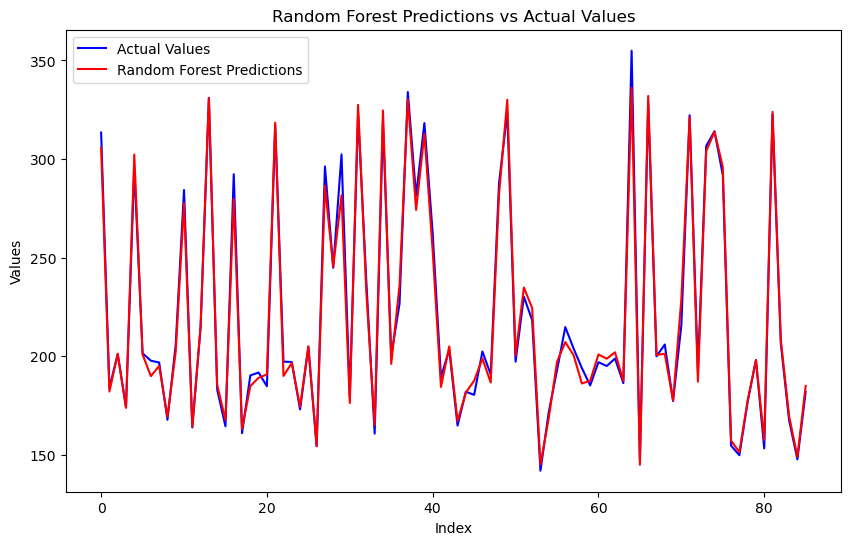

ADF Statistic: -9.507670557085026
p-value: 3.3135958481994975e-16
Best ARIMA model: ARIMA(1, 0, 2)


NameError: name 'series_hold_out' is not defined

In [25]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Suppress warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
warnings.filterwarnings("ignore", category=UserWarning)

# Load the ERCOT data
df = pd.read_csv("ercot_load_data.csv")
df["date"] = pd.to_datetime(df["date"])  # Ensure 'date' is in datetime format
df["values"] = pd.to_numeric(
    df["values"], errors="coerce"
)  # Convert 'values' to numeric
df = df.sort_values("date")  # Sort by date
df = df.dropna()  # Drop rows with missing or NaN values

# Resample the data to hourly frequency
df = (
    df.set_index("date").resample("h").mean().reset_index()
)  # Resample and take the mean for each hour

# Define hold-out period
hold_out_hours = 24  # 24 hours = 1 day
train = df.iloc[:-hold_out_hours]
hold_out = df.iloc[-hold_out_hours:]

# Generate Lagged Features
df["lag_1"] = df["values"].shift(1)
df["lag_2"] = df["values"].shift(2)
df["rate_of_change"] = df["values"].diff()

# Target for Classification: 1 if increase, 0 if decrease
df["direction"] = (df["values"].shift(-1) > df["values"]).astype(int)

# Target for Regression: Next Value
df["next_value"] = df["values"].shift(-1)

# Drop NaN Rows (after generating lag features)
df = df.dropna()

# Train-Test Split
X = df[["values", "lag_1", "lag_2", "rate_of_change"]]
y_class = df["direction"]
y_reg = df["next_value"]
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = (
    train_test_split(X, y_class, y_reg, test_size=0.2, random_state=42)
)

# Classification Model: Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_class_train)

# Add Classification Predictions as a Feature for Regression
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()
X_train_reg["direction_pred"] = clf.predict(X_train)
X_test_reg["direction_pred"] = clf.predict(X_test)

# Regression Model: Random Forest Regressor
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_reg_train)

# Predict Values
y_class_pred = clf.predict(X_test)
y_reg_pred = reg.predict(X_test_reg)

# Evaluate Performance
accuracy = accuracy_score(y_class_test, y_class_pred)
mae_rf = mean_absolute_error(y_reg_test, y_reg_pred)

# Plot Original Time Series
plt.figure(figsize=(10, 6))
plt.plot(df["date"], df["values"], label="Original Time Series")
plt.title("ERCOT Load Data - Original Time Series")
plt.xlabel("Date")
plt.ylabel("Load Values")
plt.legend()
plt.savefig("ercot_original_time_series.png")
plt.show()

# Plot Predictions vs Actual (Random Forest)
plt.figure(figsize=(10, 6))
plt.plot(y_reg_test.values, label="Actual Values", color="Blue")
plt.plot(y_reg_pred, label="Random Forest Predictions", color="Red")
plt.title("Random Forest Predictions vs Actual Values")
plt.xlabel("Index")
plt.ylabel("Values")
plt.legend()
plt.savefig("ercot_rf_predictions.png")
plt.show()

# ARIMA Model
y_reg_train_series = y_reg_train.diff().dropna()

# Check Stationarity (Optional)
adf_test = adfuller(y_reg_train_series)
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
if adf_test[1] > 0.05:
    print("Warning: Time series is not stationary!")

# Grid Search for ARIMA Parameters
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
best_aic = np.inf
best_pdq = None
best_model = None

for param in pdq:
    try:
        model_arima = ARIMA(y_reg_train_series, order=param)
        results_arima = model_arima.fit()
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_pdq = param
            best_model = results_arima
    except:
        continue

if best_model is not None:
    print(f"Best ARIMA model: ARIMA{best_pdq}")
    forecast = best_model.get_forecast(steps=len(series_hold_out))
    y_reg_pred_arima_diff = forecast.predicted_mean  # Predicted differenced values

    # Reverse differencing to match the original scale
    last_value = series_train["values"].iloc[-1]  # Last observed value in training data
    y_reg_pred_arima = np.cumsum(y_reg_pred_arima_diff) + last_value

    # Use the same index as the hold-out data
    y_reg_pred_arima.index = hold_out["date"]

    # Evaluate ARIMA Performance
    mae_arima = mean_absolute_error(series_hold_out["values"], y_reg_pred_arima)
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")

    # Plot Hold-Out Data and Forecast
    plt.figure(figsize=(12, 6))
    plt.plot(
        series_train["date"],
        series_train["values"],
        label="Training Data",
        color="blue",
    )
    plt.plot(
        series_hold_out["date"],
        series_hold_out["values"],
        label="Hold-Out Data",
        color="green",
    )
    plt.plot(
        y_reg_pred_arima.index,
        y_reg_pred_arima.values,
        label="ARIMA Forecast",
        color="red",
    )
    plt.title("ARIMA Forecast vs Hold-Out Data")
    plt.xlabel("Date")
    plt.ylabel("Values")
    plt.legend()
    plt.savefig("arima_forecast_vs_holdout.png")
    plt.show()

    # Plot Residuals (ARIMA)
    residuals_arima = series_hold_out["values"].values - y_reg_pred_arima.values
    plt.figure(figsize=(12, 6))
    plt.plot(
        series_hold_out["date"],
        residuals_arima,
        label="ARIMA Residuals",
        color="purple",
    )
    plt.axhline(0, color="red", linestyle="--", label="Zero Error Line")
    plt.title("ARIMA Residuals")
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.legend()
    plt.savefig("arima_residuals.png")
    plt.show()
else:
    print("No valid ARIMA model found.")

Classification Accuracy (Random Forest): 0.84
Regression Mean Absolute Error (Random Forest): 4.04


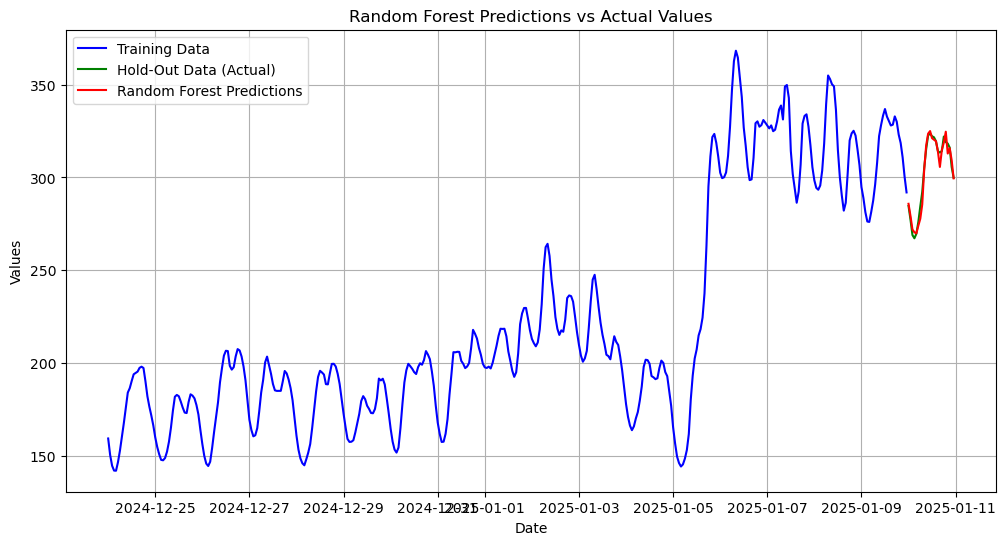

ADF Statistic: -7.541950105966102
p-value: 3.35995268737203e-11
Best ARIMA model: ARIMA(2, 0, 2)
Regression Mean Absolute Error (ARIMA): 14.27


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


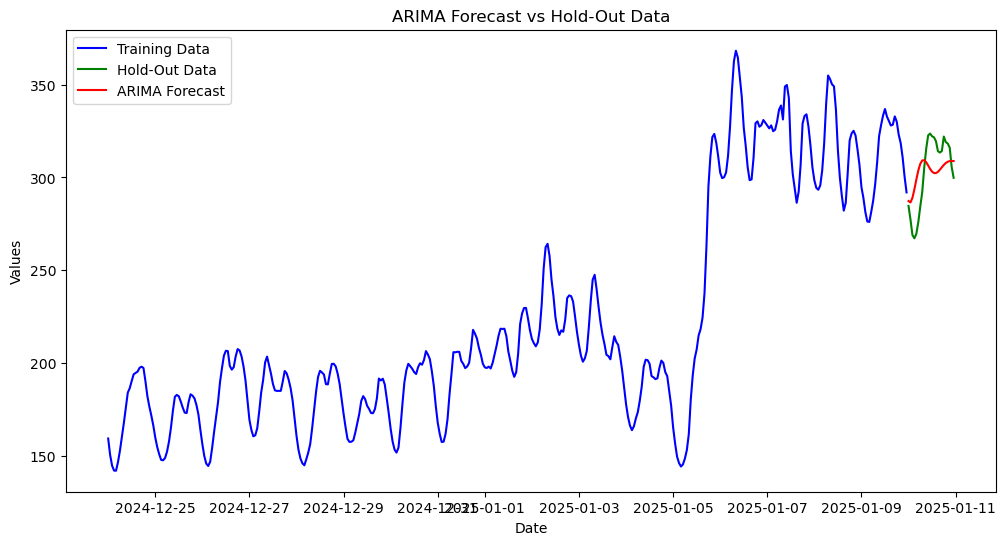

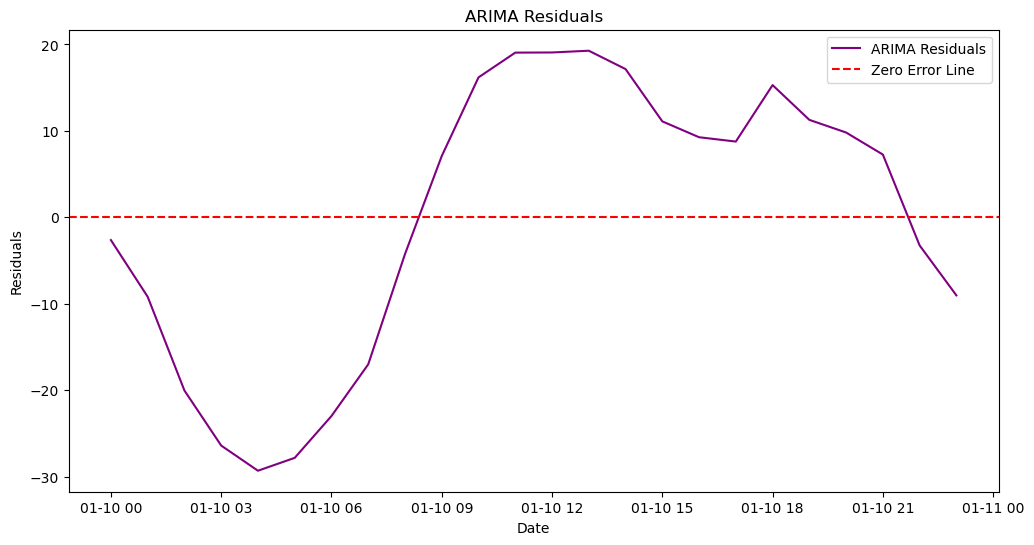

Classification Accuracy (Random Forest): 0.84
Regression Mean Absolute Error (Random Forest): 4.04
Regression Mean Absolute Error (ARIMA): 14.27


In [39]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# Suppress warnings
warnings.filterwarnings("ignore", message="Non-invertible starting MA parameters found")
warnings.filterwarnings("ignore", category=UserWarning)

# Load the ERCOT data
df = pd.read_csv("ercot_load_data.csv")
df["date"] = pd.to_datetime(df["date"])  # Ensure 'date' is in datetime format
df["values"] = pd.to_numeric(
    df["values"], errors="coerce"
)  # Convert 'values' to numeric
df = df.sort_values("date")  # Sort by date
df = df.dropna()  # Drop rows with missing or NaN values

# Resample the data to hourly frequency
df = (
    df.set_index("date").resample("h").mean().reset_index()
)  # Resample and take the mean for each hour

# Define hold-out period
hold_out_hours = 24  # 24 hours = 1 day
train = df.iloc[:-hold_out_hours]
hold_out = df.iloc[-hold_out_hours:]

# Generate Lagged Features
df["lag_1"] = df["values"].shift(1)
df["lag_2"] = df["values"].shift(2)
df["rate_of_change"] = df["values"].diff()

# Target for Classification: 1 if increase, 0 if decrease
df["direction"] = (df["values"].shift(-1) > df["values"]).astype(int)

# Target for Regression: Next Value
df["next_value"] = df["values"].shift(-1)

# Drop NaN Rows (after generating lag features)
df = df.dropna()

# Train-Test Split
X = df[["values", "lag_1", "lag_2", "rate_of_change"]]
y_class = df["direction"]
y_reg = df["next_value"]
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = (
    train_test_split(X, y_class, y_reg, test_size=0.2, random_state=42)
)

# Classification Model: Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_class_train)

# Add Classification Predictions as a Feature for Regression
X_train_reg = X_train.copy()
X_test_reg = X_test.copy()
X_train_reg["direction_pred"] = clf.predict(X_train)
X_test_reg["direction_pred"] = clf.predict(X_test)

# Regression Model: Random Forest Regressor
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_reg, y_reg_train)

# Predict Values
y_class_pred = clf.predict(X_test)
y_reg_pred = reg.predict(X_test_reg)

# Evaluate Performance
accuracy = accuracy_score(y_class_test, y_class_pred)
mae_rf = mean_absolute_error(y_reg_test, y_reg_pred)
print(f"Classification Accuracy (Random Forest): {accuracy:.2f}")
print(f"Regression Mean Absolute Error (Random Forest): {mae_rf:.2f}")

# Correct Hold-Out Data Length
X_hold_out = df[["values", "lag_1", "lag_2", "rate_of_change"]].iloc[
    -hold_out_hours:
]  # Features for hold-out period
y_hold_out_actual = df["values"].iloc[
    -hold_out_hours:
]  # Actual values for hold-out period

# Add classification predictions to hold-out features
X_hold_out["direction_pred"] = clf.predict(X_hold_out)

# Generate predictions for the hold-out period
y_hold_out_pred = reg.predict(X_hold_out)

# Combine Data for Plotting
train_data = train[["date", "values"]]
hold_out_data = hold_out[["date", "values"]].reset_index(drop=True)
predicted_data = hold_out_data.copy()
predicted_data["predicted_values"] = y_hold_out_pred

# Plot Training Data, Hold-Out Data, and Predictions
plt.figure(figsize=(12, 6))
plt.plot(train_data["date"], train_data["values"], label="Training Data", color="blue")
plt.plot(
    hold_out_data["date"],
    hold_out_data["values"],
    label="Hold-Out Data (Actual)",
    color="green",
)
plt.plot(
    predicted_data["date"],
    predicted_data["predicted_values"],
    label="Random Forest Predictions",
    color="red",
)
plt.title("Random Forest Predictions vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.savefig("rf_predictions_vs_actual.png")
plt.show()


# ARIMA Model
y_reg_train_series = train["values"].diff().dropna()

# Check Stationarity (Optional)
adf_test = adfuller(y_reg_train_series)
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
if adf_test[1] > 0.05:
    print("Warning: Time series is not stationary!")

# Grid Search for ARIMA Parameters
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))
best_aic = np.inf
best_pdq = None
best_model = None

for param in pdq:
    try:
        model_arima = ARIMA(y_reg_train_series, order=param)
        results_arima = model_arima.fit()
        if results_arima.aic < best_aic:
            best_aic = results_arima.aic
            best_pdq = param
            best_model = results_arima
    except:
        continue

if best_model is not None:
    print(f"Best ARIMA model: ARIMA{best_pdq}")
    forecast = best_model.get_forecast(steps=len(hold_out))
    y_reg_pred_arima_diff = forecast.predicted_mean  # Predicted differenced values

    # Reverse differencing to match the original scale
    last_value = train["values"].iloc[-1]  # Last observed value in training data
    y_reg_pred_arima = np.cumsum(y_reg_pred_arima_diff) + last_value

    # Evaluate ARIMA Performance
    mae_arima = mean_absolute_error(hold_out["values"], y_reg_pred_arima)
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")

    # Plot Hold-Out Data and Forecast
    plt.figure(figsize=(12, 6))
    plt.plot(train["date"], train["values"], label="Training Data", color="blue")
    plt.plot(hold_out["date"], hold_out["values"], label="Hold-Out Data", color="green")
    plt.plot(
        hold_out["date"], y_reg_pred_arima.values, label="ARIMA Forecast", color="red"
    )
    plt.title("ARIMA Forecast vs Hold-Out Data")
    plt.xlabel("Date")
    plt.ylabel("Values")
    plt.legend()
    plt.savefig("arima_forecast_vs_holdout.png")
    plt.show()

    # Plot Residuals (ARIMA)
    residuals_arima = hold_out["values"].values - y_reg_pred_arima.values
    plt.figure(figsize=(12, 6))
    plt.plot(hold_out["date"], residuals_arima, label="ARIMA Residuals", color="purple")
    plt.axhline(0, color="red", linestyle="--", label="Zero Error Line")
    plt.title("ARIMA Residuals")
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.legend()
    plt.savefig("arima_residuals.png")
    plt.show()
else:
    print("No valid ARIMA model found.")

# Final Performance Comparison
print(f"Classification Accuracy (Random Forest): {accuracy:.2f}")
print(f"Regression Mean Absolute Error (Random Forest): {mae_rf:.2f}")
if best_model is not None:
    print(f"Regression Mean Absolute Error (ARIMA): {mae_arima:.2f}")

In [ ]:
# Correct Hold-Out Data Length
X_hold_out = df[["values", "lag_1", "lag_2", "rate_of_change"]].iloc[
    -hold_out_hours:
]  # Features for hold-out period
y_hold_out_actual = df["values"].iloc[
    -hold_out_hours:
]  # Actual values for hold-out period

# Add classification predictions to hold-out features
X_hold_out["direction_pred"] = clf.predict(X_hold_out)

# Generate predictions for the hold-out period
y_hold_out_pred = reg.predict(X_hold_out)

# Combine Data for Plotting
train_data = train[["date", "values"]]
hold_out_data = hold_out[["date", "values"]].reset_index(drop=True)
predicted_data = hold_out_data.copy()
predicted_data["predicted_values"] = y_hold_out_pred

# Plot Training Data, Hold-Out Data, and Predictions
plt.figure(figsize=(12, 6))
plt.plot(
    train_data["date"],
    train_data["values"],
    label="Training Data",
    color="blue",
    linewidth=2,
)
plt.plot(
    hold_out_data["date"],
    hold_out_data["values"],
    label="Hold-Out Data (Actual)",
    color="green",
    linewidth=2,
)
plt.plot(
    predicted_data["date"],
    predicted_data["predicted_values"],
    label="Random Forest Predictions",
    color="red",
    linestyle="--",
    linewidth=2,
)
plt.title("Random Forest Predictions vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.savefig("rf_predictions_vs_actual.png")
plt.show()